This notebook contains all the code needed to reproduce figure 3-4 (convective closure parameter sweeps). 

Please be especially sure to read the instructions carefully in this notebook, otherwise you may end up waiting much longer than you need to for the code to run! 

In [10]:
import matplotlib.pyplot as plt
from mpl_toolkits import axisartist
import numpy as np

from ep_processing import *
from utils.visualization import * 

# Plotting stuff
TITLE_FONT_SIZE = 20
TICK_FONT_SIZE = 21
XAXIS_TITLE_FONT_SIZE = 24

plt.rc('axes', labelsize = TITLE_FONT_SIZE)
plt.rc('xtick', labelsize = TICK_FONT_SIZE, direction = "out") 
plt.rc('ytick', labelsize = TICK_FONT_SIZE, direction = "out")

default_markersize = 40
default_minor_markersize = 12
default_linewidth = 4

We start with a helper function: 

In [2]:
def save_list_as_txt(fname, my_list):
    return np.savetxt(fname + ".txt", np.array(my_list))

We also need a flag for if we want to reproduce fig. 3 (tropical) or fig. 4 (midlatitude). 

In [14]:
figure_region = "tropical" #  "midlatitude"

if figure_region == "tropical": 
    data_dir_path = "sm04-data/tropical/" # for figure 3

if figure_region == "midlatitude":
    data_dir_path = "sm04-data/midlatitude/" # for figure 4. 

The following code box processes the required output from our parameter sweeps. It takes a very long time to run, so once processing is complete, the processed data is saved in a directory called `sm04-data`. 

**You only need to run this code box twice: once to do the processing for fig. 3, and once for fig. 4.** Simply change the flag `figure_region` above to swithc between figures. Once you have done this, the processed data is available and you may comment the code in this box out. 

This code is admittedly not DRY (to say the least). If requested I would be happy to spend some time condensing it. 

In [4]:
my_experiment_name = "amip"
year_start = 2004
year_end = 2008 + 1
year_range = range(year_start, year_end)

default_markersize = 20

my_base_path = "~/Documents/research/experiment-outputs/{experiment_name}/{runid}/"
my_file_path = "{var_name}_day_CanESM5-1_{experiment_name}_r1i1p1f1_gn_{year}0101-{year}1231.nc"
my_areacell_path = "areacella_fx_CanESM5-1_amip_r1i1p1f1_gn.nc"

# First we load the baseline AMIP simulation (results of experiment 1)
baseline_runid = "agm-amip-test"

if figure_region == "tropical":
    central_latitude = 0. 

if figure_region == "midlatitude":
    central_latitude = 45. 

halfwidth = 13.

# Get data from CanAM defaults 
if figure_region == "tropical":
    pr_total_baseline, pr_convective_baseline, pr_resolved_baseline = get_lat_slice_ep_areamean_from_experiment(
        baseline_runid,
        my_experiment_name,
        year_range,
        base_path = my_base_path,
        file_path = my_file_path,
        areacell_path = my_areacell_path,
        central_latitude = central_latitude,
        halfwidth = halfwidth,
    )

    # Means over all days
    avgpr_total_baseline, avgpr_convective_baseline, avgpr_resolved_baseline = get_lat_slice_avgp_areamean_from_experiment(
        baseline_runid,
        my_experiment_name,
        year_range,
        base_path = my_base_path,
        file_path = my_file_path,
        areacell_path = my_areacell_path,
        central_latitude = central_latitude,
        halfwidth = halfwidth,
    )

if figure_region == "midlatitude":

    # Means over all EPEs. 
    pr_total_baseline, pr_convective_baseline, pr_resolved_baseline = get_midlat_ep_areamean_from_experiment(
        baseline_runid,
        my_experiment_name,
        year_range,
        base_path = my_base_path,
        file_path = my_file_path,
        areacell_path = my_areacell_path,
        central_latitude = central_latitude,
        halfwidth = halfwidth,
    )
    
    # Means over all days
    avgpr_total_baseline, avgpr_convective_baseline, avgpr_resolved_baseline = get_midlat_avgp_areamean_from_experiment(
        baseline_runid,
        my_experiment_name,
        year_range,
        base_path = my_base_path,
        file_path = my_file_path,
        areacell_path = my_areacell_path,
        central_latitude = central_latitude,
        halfwidth = halfwidth,
    )

# ****ALPHA EXPERIMENTS****
alpha_str = ["2e6", "2e7", "2e8", "5e8", "2e9", "2e10"]
alpha = [float(a_str) for a_str in alpha_str]

pr_total_alpha = []
pr_convective_alpha = []
pr_resolved_alpha = []

avgpr_total_alpha = []
avgpr_convective_alpha = []
avgpr_resolved_alpha = []

# Load all other experimental results
for a_str in alpha_str:
    if a_str == "5e8":
        pr_total_experiment, pr_convective_experiment, pr_resolved_experiment = pr_total_baseline, pr_convective_baseline, pr_resolved_baseline
        avgpr_total_experiment, avgpr_convective_experiment, avgpr_resolved_experiment = avgpr_total_baseline, avgpr_convective_baseline, avgpr_resolved_baseline
    else:
        sm_runid = "agm-sm04-alpha-" + a_str

        if figure_region == "tropical": 
            pr_total_experiment, pr_convective_experiment, pr_resolved_experiment = get_lat_slice_ep_areamean_from_experiment(
                sm_runid,
                my_experiment_name,
                year_range,
                base_path = my_base_path,
                file_path = my_file_path,
                areacell_path = my_areacell_path,
                central_latitude = central_latitude,
                halfwidth = halfwidth,
            )
        avgpr_total_experiment, avgpr_convective_experiment, avgpr_resolved_experiment = get_lat_slice_avgp_areamean_from_experiment(
                sm_runid,
                my_experiment_name,
                year_range,
                base_path = my_base_path,
                file_path = my_file_path,
                areacell_path = my_areacell_path,
                central_latitude = central_latitude,
                halfwidth = halfwidth,
            )

        if figure_region == "midlatitude": 
    
            pr_total_experiment, pr_convective_experiment, pr_resolved_experiment = get_midlat_ep_areamean_from_experiment(
                sm_runid,
                my_experiment_name,
                year_range,
                base_path = my_base_path,
                file_path = my_file_path,
                areacell_path = my_areacell_path,
                central_latitude = central_latitude,
                halfwidth = halfwidth,
            )
            avgpr_total_experiment, avgpr_convective_experiment, avgpr_resolved_experiment = get_midlat_avgp_areamean_from_experiment(
                sm_runid,
                my_experiment_name,
                year_range,
                base_path = my_base_path,
                file_path = my_file_path,
                areacell_path = my_areacell_path,
                central_latitude = central_latitude,
                halfwidth = halfwidth,
            )
            
    pr_total_alpha.append(pr_total_experiment)
    pr_convective_alpha.append(pr_convective_experiment)
    pr_resolved_alpha.append(pr_resolved_experiment)

    avgpr_total_alpha.append(avgpr_total_experiment)
    avgpr_convective_alpha.append(avgpr_convective_experiment)
    avgpr_resolved_alpha.append(avgpr_resolved_experiment)

save_list_as_txt(data_dir_path + "sm04-alpha-epe-total", pr_total_alpha)
save_list_as_txt(data_dir_path + "sm04-alpha-epe-param", pr_convective_alpha)
save_list_as_txt(data_dir_path + "sm04-alpha-epe-resolved", pr_resolved_alpha)

save_list_as_txt(data_dir_path + "sm04-alpha-avg-total", avgpr_total_alpha)
save_list_as_txt(data_dir_path +"sm04-alpha-avg-param", avgpr_convective_alpha)
save_list_as_txt(data_dir_path +"sm04-alpha-avg-resolved", avgpr_resolved_alpha)

# ****TAU_D EXPERIMENTS****
taud_str = ["12e2", "8e3", "148e2", "21600", "284e2"]
taud = [float(t_str) for t_str in taud_str]

pr_total_taud = []
pr_convective_taud = []
pr_resolved_taud = []

avgpr_total_taud = []
avgpr_convective_taud = []
avgpr_resolved_taud = []

for t_str in taud_str:
    if t_str == "21600":
        pr_total_experiment, pr_convective_experiment, pr_resolved_experiment = pr_total_baseline, pr_convective_baseline, pr_resolved_baseline
        avgpr_total_experiment, avgpr_convective_experiment, avgpr_resolved_experiment = avgpr_total_baseline, avgpr_convective_baseline, avgpr_resolved_baseline

    else:
        sm_runid = "agm-sm04-taud-" + t_str

        if figure_region == "tropical": 
            pr_total_experiment, pr_convective_experiment, pr_resolved_experiment = get_lat_slice_ep_areamean_from_experiment(
                sm_runid,
                my_experiment_name,
                year_range,
                base_path = my_base_path,
                file_path = my_file_path,
                areacell_path = my_areacell_path,
                central_latitude = central_latitude,
                halfwidth = halfwidth,
            )
        avgpr_total_experiment, avgpr_convective_experiment, avgpr_resolved_experiment = get_lat_slice_avgp_areamean_from_experiment(
                sm_runid,
                my_experiment_name,
                year_range,
                base_path = my_base_path,
                file_path = my_file_path,
                areacell_path = my_areacell_path,
                central_latitude = central_latitude,
                halfwidth = halfwidth,
            )

        if figure_region == "midlatitude": 
    
            pr_total_experiment, pr_convective_experiment, pr_resolved_experiment = get_midlat_ep_areamean_from_experiment(
                sm_runid,
                my_experiment_name,
                year_range,
                base_path = my_base_path,
                file_path = my_file_path,
                areacell_path = my_areacell_path,
                central_latitude = central_latitude,
                halfwidth = halfwidth,
            )
            avgpr_total_experiment, avgpr_convective_experiment, avgpr_resolved_experiment = get_midlat_avgp_areamean_from_experiment(
                sm_runid,
                my_experiment_name,
                year_range,
                base_path = my_base_path,
                file_path = my_file_path,
                areacell_path = my_areacell_path,
                central_latitude = central_latitude,
                halfwidth = halfwidth,
            )

    pr_total_taud.append(pr_total_experiment)
    pr_convective_taud.append(pr_convective_experiment)
    pr_resolved_taud.append(pr_resolved_experiment)

    avgpr_total_taud.append(avgpr_total_experiment)
    avgpr_convective_taud.append(avgpr_convective_experiment)
    avgpr_resolved_taud.append(avgpr_resolved_experiment)

save_list_as_txt(data_dir_path + "sm04-taud-epe-total", pr_total_taud)
save_list_as_txt(data_dir_path + "sm04-taud-epe-param", pr_convective_taud)
save_list_as_txt(data_dir_path + "sm04-taud-epe-resolved", pr_resolved_taud)

save_list_as_txt(data_dir_path + "sm04-taud-avg-total", avgpr_total_taud)
save_list_as_txt(data_dir_path + "sm04-taud-avg-param", avgpr_convective_taud)
save_list_as_txt(data_dir_path + "sm04-taud-avg-resolved", avgpr_resolved_taud)

Now, the data is processed and we can reproduce figures 3 and 4. **Again, this code will not work unless you have run the block above!**

In [15]:
avgpr_convective_alpha = np.loadtxt(data_dir_path + "sm04-alpha-avg-param.txt")
avgpr_resolved_alpha = np.loadtxt(data_dir_path + "sm04-alpha-avg-resolved.txt")
avgpr_total_alpha = np.loadtxt(data_dir_path + "sm04-alpha-avg-total.txt")
ax00_content = np.stack([avgpr_convective_alpha, avgpr_resolved_alpha, avgpr_total_alpha])

pr_convective_alpha = np.loadtxt(data_dir_path + "sm04-alpha-epe-param.txt")
pr_resolved_alpha = np.loadtxt(data_dir_path + "sm04-alpha-epe-resolved.txt")
pr_total_alpha = np.loadtxt(data_dir_path + "sm04-alpha-epe-total.txt")
ax01_content = np.stack([pr_convective_alpha, pr_resolved_alpha, pr_total_alpha])

avgpr_convective_taud = np.loadtxt(data_dir_path + "sm04-taud-avg-param.txt")
avgpr_resolved_taud = np.loadtxt(data_dir_path + "sm04-taud-avg-resolved.txt")
avgpr_total_taud = np.loadtxt(data_dir_path + "sm04-taud-avg-total.txt")
ax10_content = np.stack([avgpr_convective_taud, avgpr_resolved_taud, avgpr_total_taud])

pr_convective_taud = np.loadtxt(data_dir_path + "sm04-taud-epe-param.txt")
pr_resolved_taud = np.loadtxt(data_dir_path + "sm04-taud-epe-resolved.txt")
pr_total_taud = np.loadtxt(data_dir_path + "sm04-taud-epe-total.txt")
ax11_content = np.stack([pr_convective_taud, pr_resolved_taud, pr_total_taud])

ax_contents = [ax00_content, ax01_content, ax10_content, ax11_content]

In [16]:
alpha_str = ["2e6", "2e7", "2e8", "5e8", "2e9", "2e10"]
alpha = [float(a_str) for a_str in alpha_str]

taud_str = ["12e2", "8e3", "148e2", "21600", "284e2"]
taud = [float(t_str) for t_str in taud_str]

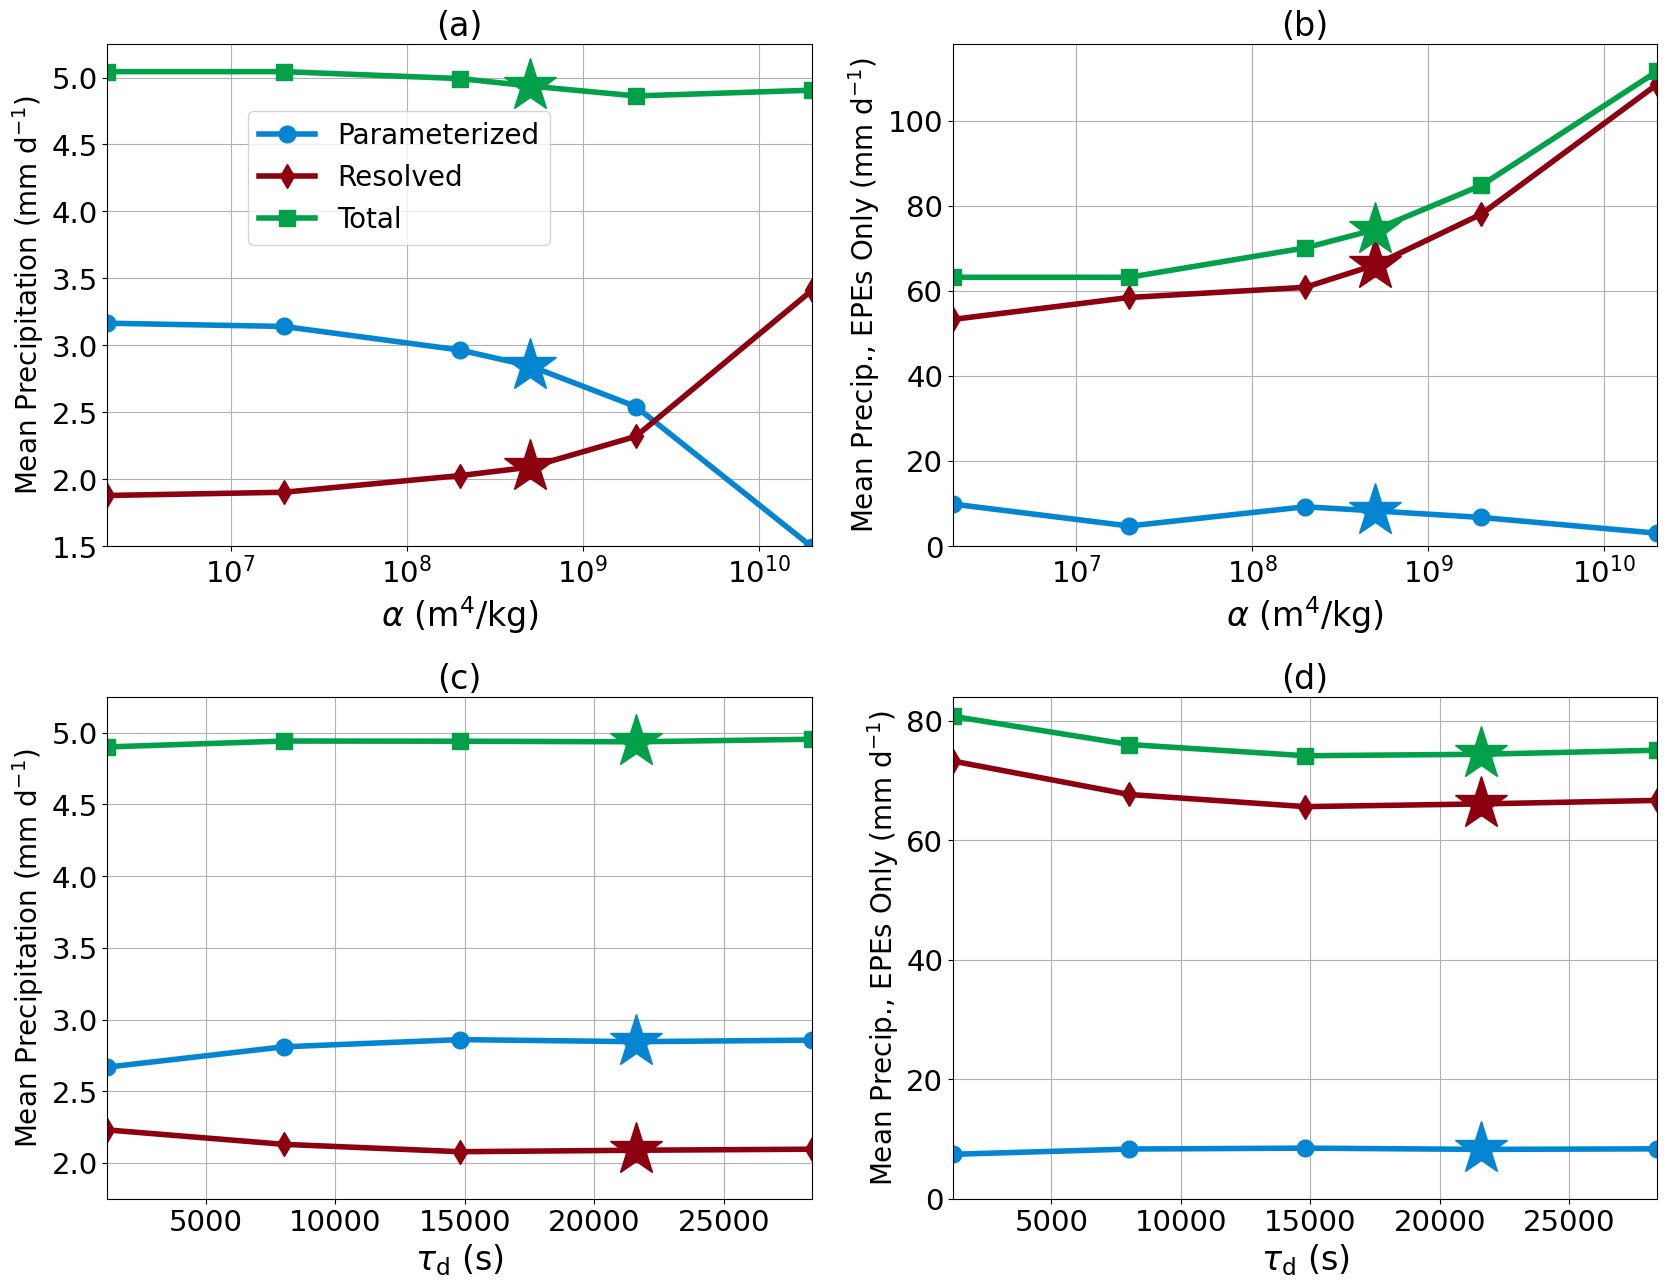

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(20, 15))
plt.subplots_adjust(hspace=0.3)

row_idx = 0
col_idx = 0

for ax_content in ax_contents:
    ax = axes[row_idx, col_idx]

    ax.grid("on")

    if row_idx == 0:

        ax.semilogx(alpha,
                     ax_content[0],
                     color = "xkcd:cerulean",
                     marker = "o",
                     linestyle = "solid",
                     label = "Parameterized",
                     linewidth = default_linewidth,
                     markersize = default_minor_markersize,
                    )
        
        ax.semilogx(5e8,
                    ax_content[0][3],
                    color = "xkcd:cerulean",
                    marker= "*",
                    markersize =  default_markersize,
                   )
        
        ax.semilogx(alpha,
                     ax_content[1],
                     color = "xkcd:crimson",
                     marker = "d",
                     linestyle = "solid",
                     label = "Resolved",
                     linewidth = default_linewidth,
                     markersize = default_minor_markersize,
                    )
        
        ax.semilogx(5e8,
                    ax_content[1][3],
                    color = "xkcd:crimson",
                    marker= "*",
                    markersize =  default_markersize,
                   )
    
        ax.semilogx(alpha,
                     ax_content[2],
                     color = "xkcd:emerald",
                     marker = "s",
                     linestyle = "solid",
                     label= "Total",
                     linewidth = default_linewidth,
                     markersize = default_minor_markersize,
                    )
    
        ax.semilogx(5e8,
                    ax_content[2][3],
                    color = "xkcd:emerald",
                    marker= "*",
                    markersize =  default_markersize,
                    )

        ax.set_xlim(left = min(alpha), right = max(alpha))
        ax.set_xlabel(r"$\alpha$ ($\mathrm{m}^4$/kg)", fontsize = XAXIS_TITLE_FONT_SIZE)

        if col_idx == 0:
            
            ax.set_ylabel(r"Mean Precipitation (mm $\mathrm{d}^{-1}$)", fontsize = TITLE_FONT_SIZE)

            if figure_region == "tropical":
                ax.legend(fontsize = TITLE_FONT_SIZE, loc = (0.2, 0.6)) # tropical 
                ax.set_ylim(1.5, 5.25) # tropical

            if figure_region == "midlatitude":
                ax.legend(fontsize = TITLE_FONT_SIZE, loc = (0.2, 0.285)) # midlat
                
            ax.set_title("(a)", fontsize = XAXIS_TITLE_FONT_SIZE)

        if col_idx == 1:
            
            ax.set_ylabel(r"Mean Precip., EPEs Only (mm $\mathrm{d}^{-1}$)", fontsize = TITLE_FONT_SIZE)
            ax.set_title("(b)", fontsize = XAXIS_TITLE_FONT_SIZE)
            
            if figure_region == "tropical":
                ax.set_ylim(0, 118) # tropical

    if row_idx == 1:
        
        ax.plot(
            taud, 
            ax_content[2], 
            color = "xkcd:emerald",
            marker = "s",
            linestyle = "solid",
            label= "Total",
            linewidth = default_linewidth,
            markersize = default_minor_markersize,
        )

        ax.plot(21600,
            ax_content[2][3],
            color = "xkcd:emerald",
            marker= "*",
            markersize =  default_markersize,
        )

        ax.plot(taud,
         ax_content[0],
         color = "xkcd:cerulean",
         marker = "o",
         linestyle = "solid",
         label = "Parameterized",
         linewidth = default_linewidth,
         markersize = default_minor_markersize,
        )

        ax.plot(21600,
            ax_content[0][3],
            color = "xkcd:cerulean",
            marker= "*",
            markersize =  default_markersize,
            )

        ax.plot(taud,
         ax_content[1],
         color = "xkcd:crimson",
         marker = "d",
         linestyle = "solid",
         label = "Resolved",
         linewidth = default_linewidth,
         markersize = default_minor_markersize,
        )

        ax.plot(21600,
           ax_content[1][3],
            color = "xkcd:crimson",
            marker= "*",
            markersize =  default_markersize,
            )

        ax.set_xlabel(r"$\tau_{\mathrm{d}}$ (s)", fontsize = XAXIS_TITLE_FONT_SIZE)
        ax.set_xlim(min(taud), max(taud))

        if col_idx == 0:
            
            ax.set_ylabel(r"Mean Precipitation (mm $\mathrm{d}^{-1}$)", fontsize = TITLE_FONT_SIZE)
            ax.set_title("(c)", fontsize = XAXIS_TITLE_FONT_SIZE)

            if figure_region == "tropical":
                ax.set_ylim(1.75, 5.25) # tropical values

        if col_idx == 1:

            ax.set_ylabel(r"Mean Precip., EPEs Only (mm $\mathrm{d}^{-1}$)", fontsize = TITLE_FONT_SIZE)
            ax.set_title("(d)", fontsize = XAXIS_TITLE_FONT_SIZE)

            if figure_region == "tropical":
                ax.set_ylim(0,84) # tropical values
        
    ax.minorticks_off()

    if col_idx == 1:
        row_idx = 1
    
    col_idx += 1
    col_idx = col_idx % 2
    
# Save output
#outfile_path = "images/" + "sm04-gallery-" + figure_region + ".png"
#plt.savefig(outfile_path, dpi=600, bbox_inches='tight')

plt.show()